# Phase 2 & 3: Feature Engineering + Logistic Regression Baseline

**Goals:**
1. Scale features and create stratified train/val/test splits
2. Compare three imbalance-handling strategies (class weights, SMOTE, undersampling)
3. Train a logistic regression baseline — understand *why accuracy is useless*
4. Establish AUC-PR as the primary metric going forward

**Data source:** AWS S3 (configured in `config/aws_config.py`)

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay
)
from src.preprocessing import load_data, scale_features, split_data, apply_smote, undersample_majority
from config.aws_config import read_csv_from_s3, S3_DATA_PREFIX, S3_BUCKET

sns.set_theme(style='whitegrid')
%matplotlib inline

✓ AWS S3 configured: eu-central-1 / raw-creditcard-fraud-data-v1-759302162548-eu-central-1-an


## 1. Load & Preprocess

In [2]:
# Load data from S3
s3_key = f"{S3_DATA_PREFIX}/creditcard.csv"
df = read_csv_from_s3(s3_key)

print(f'Loaded from S3: s3://{S3_BUCKET}/{s3_key}')

# Preprocess
from src.preprocessing import scale_features, split_data
df = scale_features(df)

X_train, X_val, X_test, y_train, y_val, y_test = split_data(df)

print(f'Train: {X_train.shape}, fraud={y_train.sum()} ({y_train.mean()*100:.3f}%)')
print(f'Val:   {X_val.shape},   fraud={y_val.sum()} ({y_val.mean()*100:.3f}%)')
print(f'Test:  {X_test.shape},  fraud={y_test.sum()} ({y_test.mean()*100:.3f}%)')

Loaded from S3: s3://raw-creditcard-fraud-data-v1-759302162548-eu-central-1-an/data/raw/creditcard.csv
Train: (199364, 30), fraud=344 (0.173%)
Val:   (42721, 30),   fraud=74 (0.173%)
Test:  (42722, 30),  fraud=74 (0.173%)


## 2. Why Accuracy Is Misleading

Let's first see what happens if we build the world's laziest model.

In [3]:
# "Always predict legitimate"
y_always_legit = np.zeros(len(y_val))
acc = accuracy_score(y_val, y_always_legit)
print(f'Always-Legit model accuracy: {acc*100:.2f}%')
print(f'Fraud caught: 0 out of {y_val.sum()}')
print()
print('This is why accuracy is useless for imbalanced classification.')
print('We need metrics that specifically measure fraud detection.')

Always-Legit model accuracy: 99.83%
Fraud caught: 0 out of 74

This is why accuracy is useless for imbalanced classification.
We need metrics that specifically measure fraud detection.


## 3. Evaluation Helper

We'll use this function for all models throughout the project.

In [4]:
def evaluate_model(model, X, y, model_name='Model', threshold=0.5):
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    
    auc_roc = roc_auc_score(y, y_prob)
    auc_pr  = average_precision_score(y, y_prob)
    acc     = accuracy_score(y, y_pred)
    
    print(f'--- {model_name} (threshold={threshold}) ---')
    print(f'  Accuracy:  {acc*100:.2f}%  ← mostly useless here')
    print(f'  AUC-ROC:   {auc_roc:.4f}')
    print(f'  AUC-PR:    {auc_pr:.4f}  ← primary metric')
    print()
    print(classification_report(y, y_pred, target_names=['Legitimate', 'Fraud']))
    
    return auc_roc, auc_pr, y_prob

## 4. Baseline: Logistic Regression (no imbalance handling)

In [5]:
lr_no_weight = LogisticRegression(max_iter=1000, random_state=42)
lr_no_weight.fit(X_train, y_train)
roc1, pr1, prob1 = evaluate_model(lr_no_weight, X_val, y_val, 'LR (no weight)')

--- LR (no weight) (threshold=0.5) ---
  Accuracy:  99.91%  ← mostly useless here
  AUC-ROC:   0.9543
  AUC-PR:    0.6704  ← primary metric

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     42647
       Fraud       0.80      0.61      0.69        74

    accuracy                           1.00     42721
   macro avg       0.90      0.80      0.85     42721
weighted avg       1.00      1.00      1.00     42721



## 5. Strategy 1: Class Weights

In [6]:
lr_weighted = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_weighted.fit(X_train, y_train)
roc2, pr2, prob2 = evaluate_model(lr_weighted, X_val, y_val, 'LR (class_weight=balanced)')

--- LR (class_weight=balanced) (threshold=0.5) ---
  Accuracy:  97.86%  ← mostly useless here
  AUC-ROC:   0.9684
  AUC-PR:    0.6301  ← primary metric

              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     42647
       Fraud       0.07      0.88      0.12        74

    accuracy                           0.98     42721
   macro avg       0.53      0.93      0.56     42721
weighted avg       1.00      0.98      0.99     42721



## 6. Strategy 2: SMOTE Oversampling

In [7]:
X_train_smote, y_train_smote = apply_smote(X_train, y_train)
print(f'After SMOTE: {X_train_smote.shape}, fraud rate: {y_train_smote.mean()*100:.1f}%')

lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)
roc3, pr3, prob3 = evaluate_model(lr_smote, X_val, y_val, 'LR (SMOTE)')

After SMOTE: (398040, 30), fraud rate: 50.0%
--- LR (SMOTE) (threshold=0.5) ---
  Accuracy:  97.74%  ← mostly useless here
  AUC-ROC:   0.9662
  AUC-PR:    0.6312  ← primary metric

              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     42647
       Fraud       0.06      0.88      0.12        74

    accuracy                           0.98     42721
   macro avg       0.53      0.93      0.55     42721
weighted avg       1.00      0.98      0.99     42721



## 7. Strategy 3: Undersample Majority Class

In [8]:
X_train_under, y_train_under = undersample_majority(X_train, y_train, ratio=0.1)
print(f'After undersampling: {X_train_under.shape}, fraud rate: {y_train_under.mean()*100:.1f}%')

lr_under = LogisticRegression(max_iter=1000, random_state=42)
lr_under.fit(X_train_under, y_train_under)
roc4, pr4, prob4 = evaluate_model(lr_under, X_val, y_val, 'LR (Undersample)')

After undersampling: (3784, 30), fraud rate: 9.1%
--- LR (Undersample) (threshold=0.5) ---
  Accuracy:  99.71%  ← mostly useless here
  AUC-ROC:   0.9700
  AUC-PR:    0.6451  ← primary metric

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     42647
       Fraud       0.35      0.82      0.50        74

    accuracy                           1.00     42721
   macro avg       0.68      0.91      0.75     42721
weighted avg       1.00      1.00      1.00     42721



## 8. Comparison: Precision-Recall Curves

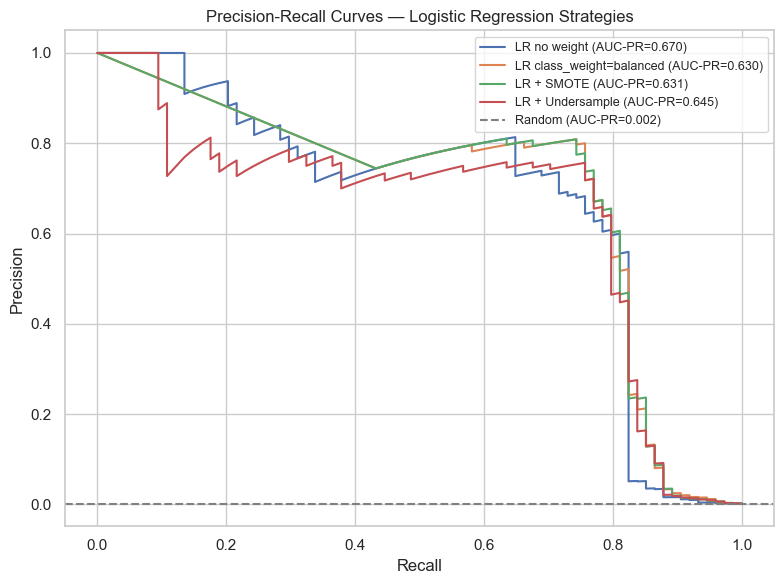


Summary:
     Strategy   AUC-PR  AUC-ROC
    No weight 0.670395 0.954307
  Undersample 0.645077 0.969998
        SMOTE 0.631204 0.966240
Class weights 0.630096 0.968350


In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

models = [
    ('LR no weight', prob1, pr1),
    ('LR class_weight=balanced', prob2, pr2),
    ('LR + SMOTE', prob3, pr3),
    ('LR + Undersample', prob4, pr4),
]

for name, probs, auc_pr in models:
    prec, rec, _ = precision_recall_curve(y_val, probs)
    ax.plot(rec, prec, label=f'{name} (AUC-PR={auc_pr:.3f})')

# Baseline: random classifier
ax.axhline(y=y_val.mean(), color='gray', linestyle='--', label=f'Random (AUC-PR={y_val.mean():.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — Logistic Regression Strategies')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('../data/pr_curves_lr.png', dpi=120)
plt.show()

print('\nSummary:')
summary = pd.DataFrame([
    {'Strategy': name, 'AUC-PR': auc_pr, 'AUC-ROC': roc}
    for name, _, auc_pr, roc in [('No weight', prob1, pr1, roc1), ('Class weights', prob2, pr2, roc2),
                                   ('SMOTE', prob3, pr3, roc3), ('Undersample', prob4, pr4, roc4)]
])
print(summary.sort_values('AUC-PR', ascending=False).to_string(index=False))

## 9. Key Takeaways

- **AUC-PR vs AUC-ROC**: AUC-ROC looks great for all models because there are so many true negatives — it inflates. AUC-PR is more informative because it focuses only on the fraud class.
- **Class weights** are the simplest effective strategy — no data augmentation needed.
- **SMOTE** creates synthetic fraud examples; can help but also risks overfitting synthetic patterns.
- **Undersampling** discards real data — useful when dataset is huge but loses information.

**Next step → `03_tree_models.ipynb`**: Replace Logistic Regression with Random Forest and XGBoost, run experiments via SageMaker.